# Random Forest Classification 

-- Can an ensemble of diverse nonlinear decision trees generalize better than the single Decision Tree?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
DATA_DIR = Path("data")

X_train = pd.read_csv(
    DATA_DIR / "(experiment) X_train.csv",
    index_col=0,
    parse_dates=True
)

y_train = pd.read_csv(
    DATA_DIR / "(experiment) y_train.csv",
    index_col=0,
    parse_dates=True
)

X_test = pd.read_csv(
    DATA_DIR / "(experiment) X_test.csv",
    index_col=0,
    parse_dates=True
)

y_test = pd.read_csv(
    DATA_DIR / "(experiment) y_test.csv",
    index_col=0,
    parse_dates=True
)

In [3]:
print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

TRAIN / TEST SPLIT
Training observations: 59
Testing observations: 18

Training period:
2007-06-30 00:00:00 to 2021-12-31 00:00:00

Testing period:
2022-03-31 00:00:00 to 2026-06-30 00:00:00

Training class distribution:
PCE_Regime
0             29
1             30
Name: count, dtype: int64

Testing class distribution:
PCE_Regime
0              8
1             10
Name: count, dtype: int64


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [7]:
# ============================================================
# RANDOM FOREST CLASSIFICATION
# PCE Growth Regime Classification
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    
    ("imputer", SimpleImputer(strategy="median")),
    
    ("forest", RandomForestClassifier(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

/usr/local/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

In [9]:
# ============================================================
# RANDOM FOREST PREDICTIONS
# ============================================================

rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

rf_predictions = pd.DataFrame({
    "Actual": y_test.squeeze(),
    "Predicted": rf_pred,
    "Probability_Strong": rf_prob
})

display(rf_predictions)

,Actual,Predicted,Probability_Strong
Quarter,,,
2022-03-31,0,1,0.778516
2022-06-30,1,1,0.702868
2022-09-30,0,1,0.550011
2022-12-31,0,1,0.515767
2023-03-31,1,1,0.512787
2023-06-30,0,1,0.510986
2023-09-30,1,1,0.519257
2023-12-31,1,1,0.502802
2024-03-31,0,1,0.519505


In [10]:
# ============================================================
# RANDOM FOREST PERFORMANCE
# ============================================================

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_balanced_accuracy = balanced_accuracy_score(
    y_test, rf_pred
)

rf_precision = precision_score(
    y_test, rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test, rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test, rf_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test, rf_prob
)


print("=" * 55)
print("RANDOM FOREST MODEL PERFORMANCE")
print("=" * 55)

print(f"Accuracy:           {rf_accuracy:.4f}")
print(f"Balanced Accuracy:  {rf_balanced_accuracy:.4f}")
print(f"Precision:          {rf_precision:.4f}")
print(f"Recall:             {rf_recall:.4f}")
print(f"F1 Score:           {rf_f1:.4f}")
print(f"ROC-AUC:            {rf_roc_auc:.4f}")

RANDOM FOREST MODEL PERFORMANCE
Accuracy:           0.5000
Balanced Accuracy:  0.4750
Precision:          0.5385
Recall:             0.7000
F1 Score:           0.6087
ROC-AUC:            0.4000


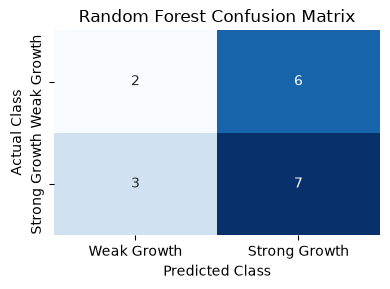

In [12]:
# ============================================================
# RANDOM FOREST CONFUSION MATRIX
# ============================================================

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(4, 3))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Weak Growth",
        "Strong Growth"
    ],
    yticklabels=[
        "Weak Growth",
        "Strong Growth"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

fitted_rf = rf_pipeline.named_steps["forest"]

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": fitted_rf.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(rf_importance.head(15))

,Feature,Importance
0,Federal Funds Rate,0.051043
1,Labor Force Participation Rate,0.036090
2,Credit Card & Revolving Loan Growth,0.035246
3,Mortgage Rate,0.032993
4,Employment Rate,0.028800
5,Corporate Bond Yield,0.026185
6,Personal Loan Rate,0.026167
7,Market Volatility (VIX),0.023502
8,Exchange Rate,0.022322
9,Delinquency Rate,0.022313


| Model               | Accuracy | Balanced Acc. |  ROC-AUC | Main finding                        |
| ------------------- | -------: | ------------: | -------: | ----------------------------------- |
| Logistic Regression | **.556** |      **.575** |     .550 | Best balanced classification so far |
| KNN                 |     .556 |          .500 |     .500 | Collapsed to Strong                 |
| Linear SVM          |     .444 |          .425 | **.575** | Weak classification                 |
| Decision Tree V1    |     .556 |          .500 |     .488 | Collapsed to Strong                 |
| Decision Tree V2    |     .444 |          .488 |     .488 | Very poor Strong recall             |
| Random Forest       |     .500 |          .475 | **.400** | Ensemble did not solve the problem  |


| Metric            | **Random Forest** | Interpretation                                               |
| ----------------- | ----------------: | ------------------------------------------------------------ |
| Accuracy          |        **0.5000** | 50% of test quarters were classified correctly               |
| Balanced Accuracy |        **0.4750** | Average performance across Weak and Strong classes was 47.5% |
| Precision         |        **0.5385** | When predicting Strong Growth, 53.85% were actually Strong   |
| Recall            |        **0.7000** | It identified 70% of the actual Strong-Growth quarters       |
| F1                |        **0.6087** | Moderate balance between precision and recall                |
| ROC-AUC           |        **0.4000** | Probability ranking was worse than random discrimination     |


### Interpretation: 

Random Forest captured more Strong-Growth observations than Logistic Regression but produced poorer overall class discrimination and the lowest ROC-AUC among these models.